In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/Telco_customer_churn.csv')
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
# Missing Values
print(df.isnull().sum()[df.isnull().sum() > 0])

Churn Reason    5174
dtype: int64


## Data Cleaning and Feature Engineering Phase

In [38]:
# Convert Total Charges from string to float
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce')
df["Total Charges"].dtypes

dtype('float64')

In [39]:
# Remove Entries that have NaN Total Charges
df.dropna(subset=['Total Charges'], inplace=True)

In [40]:
# Feature engineering
df['avg_monthly_spend'] = df['Total Charges'] / (df['Tenure Months'])


service_cols = ['Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

def multiple_services(row):
    value_dict = {
        'Yes':1,
        'No':0,
        'No internet service':0, 
        'No phone service': 0
    }
    service_count = 0
    for col in service_cols:
        if service_count <= 1:
            value = value_dict[row[col]]
            service_count += value
        else:
            return True

    return False


df['has_multiple_services'] = df.apply(multiple_services, axis=1)

In [41]:
# Convert to CSV (Cleaned and ready for training)
df.to_csv('../data/Telc_customer_churn_cleaned.csv', index=False)

Data Inspection, Cleaning and Tranformation


In [42]:
# Dataframe basic information
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             7032 non-null   str    
 1   Count                  7032 non-null   int64  
 2   Country                7032 non-null   str    
 3   State                  7032 non-null   str    
 4   City                   7032 non-null   str    
 5   Zip Code               7032 non-null   int64  
 6   Lat Long               7032 non-null   str    
 7   Latitude               7032 non-null   float64
 8   Longitude              7032 non-null   float64
 9   Gender                 7032 non-null   str    
 10  Senior Citizen         7032 non-null   str    
 11  Partner                7032 non-null   str    
 12  Dependents             7032 non-null   str    
 13  Tenure Months          7032 non-null   int64  
 14  Phone Service          7032 non-null   str    
 15  Multiple Lines      

In [43]:
print('Dataframe Shape:')
print(df.shape)
print('')
print('Dataframe tail and head:')
print(df.head(10))
print(df.tail(5))
print('')
print('Dataframe info')
print(df.info())
print('')
print('Datafram types')
print(df.dtypes)
print('')
print(df.columns.tolist())

Dataframe Shape:
(7032, 35)

Dataframe tail and head:
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   
5  4190-MFLUW      1  United States  California  Los Angeles     90020   
6  8779-QRDMV      1  United States  California  Los Angeles     90022   
7  1066-JKSGK      1  United States  California  Los Angeles     90024   
8  6467-CHFZW      1  United States  California  Los Angeles     90028   
9  8665-UTDHZ      1  United States  California  Los Angeles     90029   

                 Lat Long   Latitude   Longitude  Gender  ...  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...   
1

Data Quality Assessment


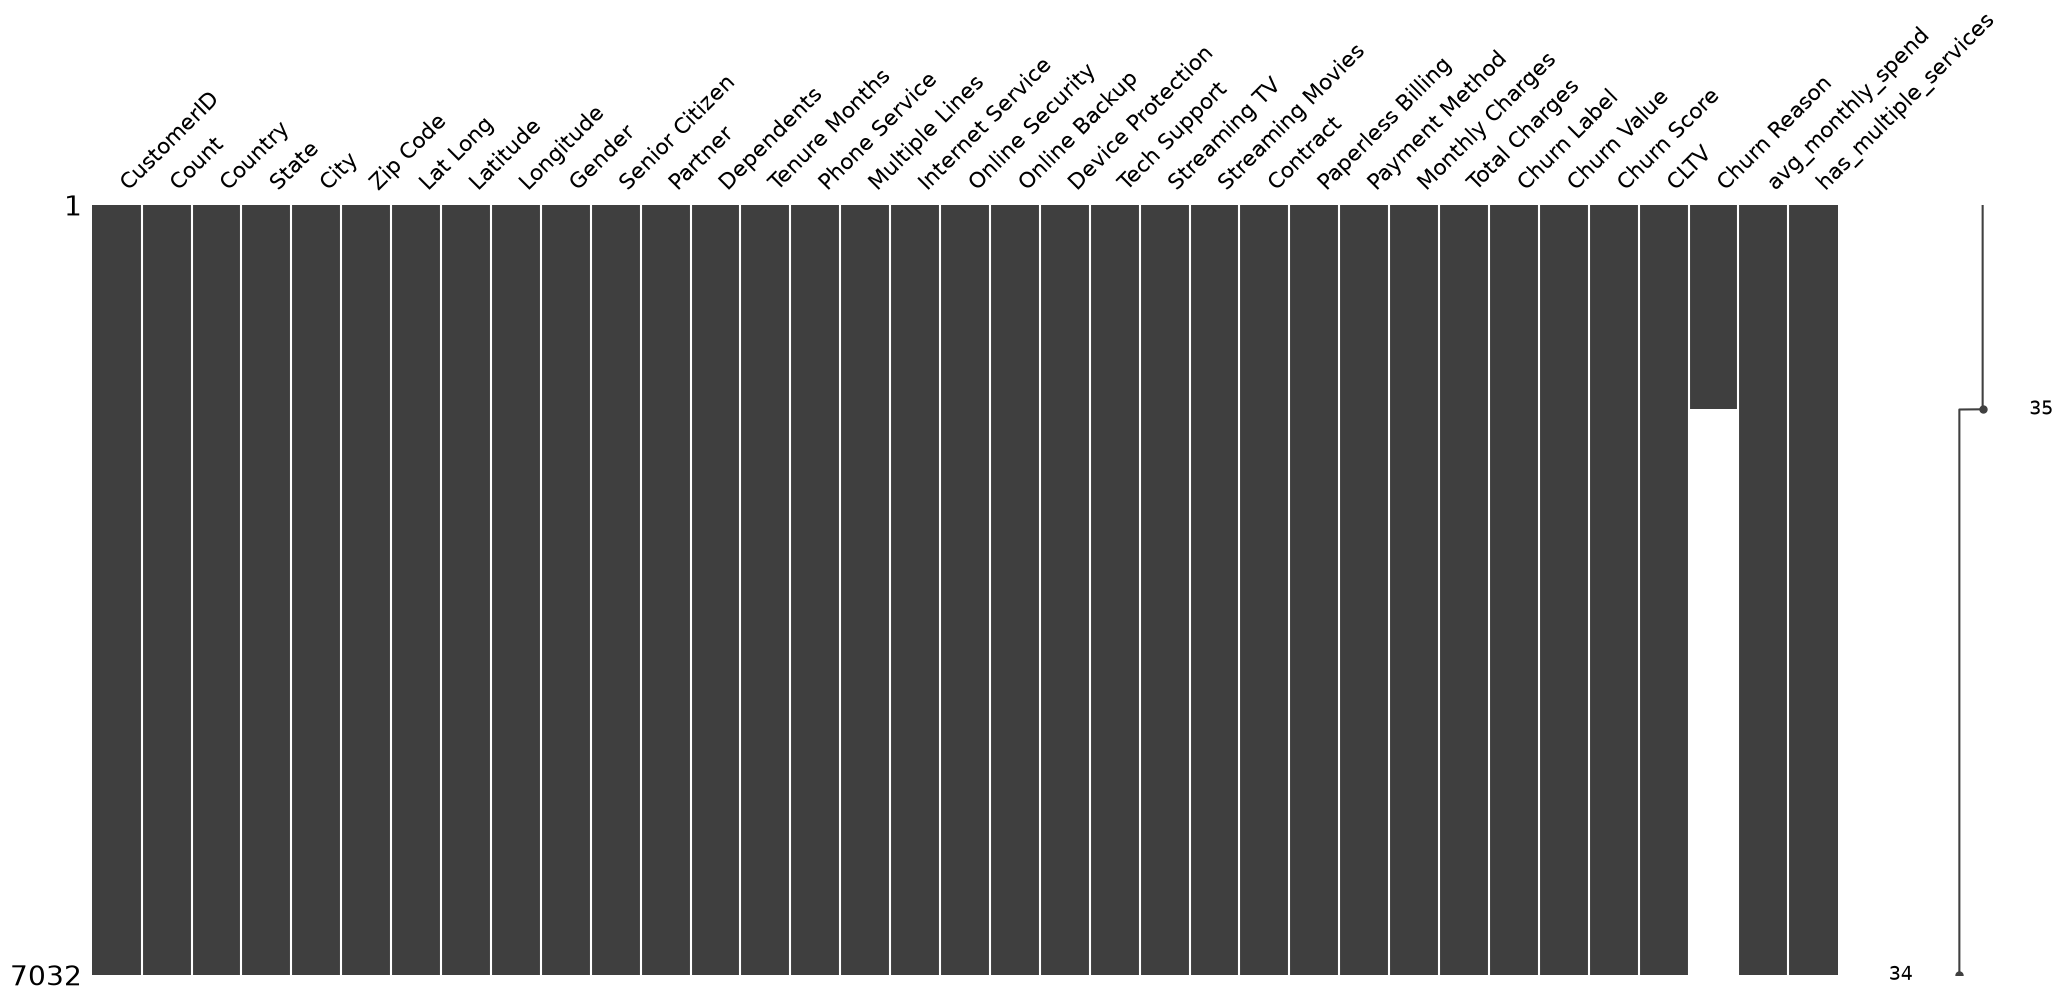

In [44]:
import missingno as msno 
msno.matrix(df)
plt.show()

### Around 73% of Churn Reason is blank (NaN)

In [11]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [12]:
# Duplicated Values
print(df.duplicated().sum())

0


In [13]:
df['Total Charges'].dtypes

dtype('float64')

In [14]:
df.groupby('Contract').agg(
    total_charges=('Total Charges', 'sum')
)

,total_charges
Contract,
Month-to-month,5305861.5
One year,4467053.5
Two year,6283253.7


In [15]:
df['Churn Value'].value_counts(normalize='True')

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## We have observed an overall 26% churn rate for this quarter


### Churn Rate per contract type


In [35]:
df.groupby('Contract')['Churn Value'].value_counts(normalize='True').reset_index()

,Contract,Churn Value,proportion
0,Month-to-month,0,0.572903
1,Month-to-month,1,0.427097
2,One year,0,0.887228
3,One year,1,0.112772
4,Two year,0,0.971513
5,Two year,1,0.028487


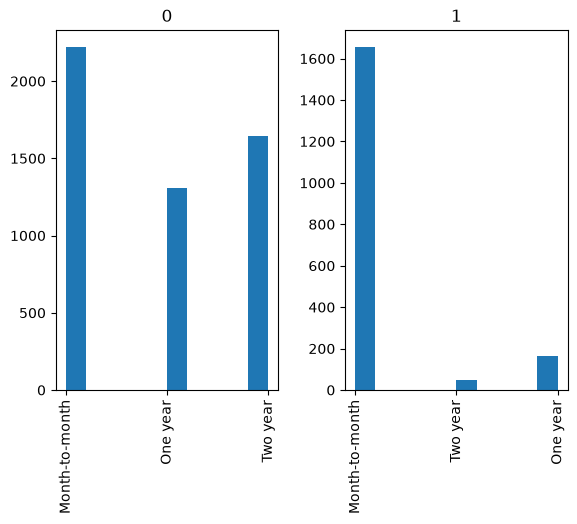

In [17]:
hist = df.hist(column='Contract', by='Churn Value')

## Churn Rate by Payment Method

In [36]:
df.groupby('Payment Method')['Churn Value'].value_counts(normalize='True').reset_index()

,Payment Method,Churn Value,proportion
0,Bank transfer (automatic),0,0.832685
1,Bank transfer (automatic),1,0.167315
2,Credit card (automatic),0,0.847469
3,Credit card (automatic),1,0.152531
4,Electronic check,0,0.547146
5,Electronic check,1,0.452854
6,Mailed check,0,0.807980
7,Mailed check,1,0.192020


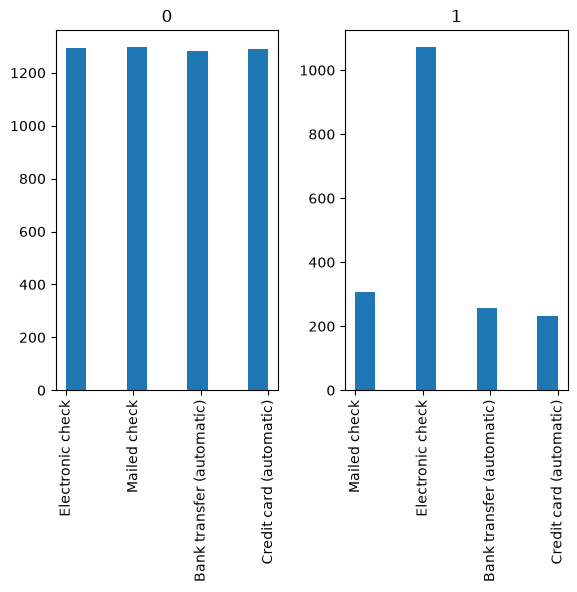

In [37]:
hist = df.hist(column='Payment Method', by='Churn Value')

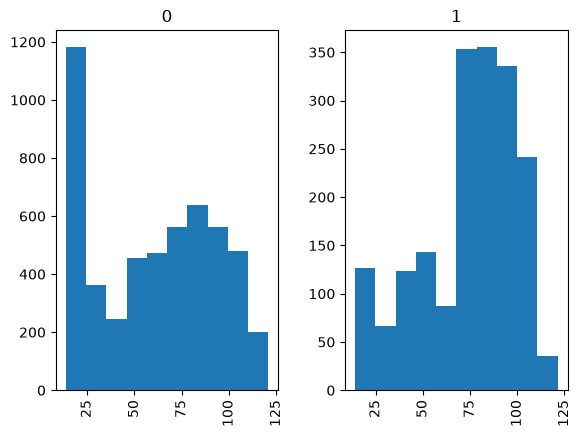

In [47]:
hist = df.hist(column='avg_monthly_spend', by='Churn Value')

Payment Method
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Electronic check             2365
Mailed check                 1604
Name: Count, dtype: int64

Text(0.5, 1.0, 'Payment methods for customers who stayed')

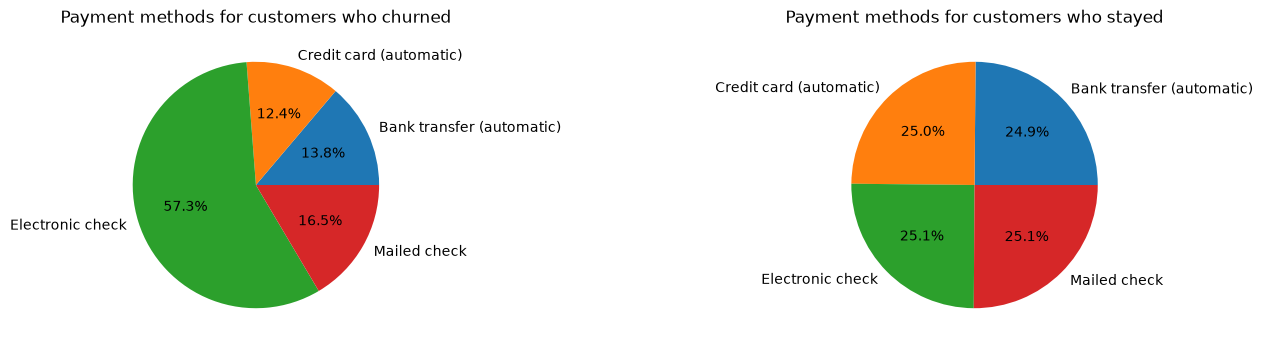

In [91]:
# Payment Methods

churned = df[df['Churn Value'] == 1].groupby('Payment Method')['Count'].count().reset_index()
stayed = df[df['Churn Value'] == 0].groupby('Payment Method')['Count'].count().reset_index()
fig, axs = plt.subplots( ncols=2, figsize=(17, 4))

# Payment methods for churned
axs[0].pie(churned['Count'], labels=churned['Payment Method'], autopct='%1.1f%%')
axs[0].set_title('Payment methods for customers who churned')

# Payment methods for those stayed
axs[1].pie(stayed['Count'], labels=stayed['Payment Method'], autopct='%1.1f%%')
axs[1].set_title('Payment methods for customers who stayed')